In [1]:
# ==========================================
#    Mount Drive and Set Project Directory
# ==========================================

import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
PROJECT_ROOT = '/content/drive/MyDrive/new_vision'
os.chdir(PROJECT_ROOT)
print("Files in this project:", os.listdir())

Mounted at /content/drive
Files in this project: ['kaggle.json', 'models', 'minicv', 'report', 'feature_ex', 'utils', 'tests_summary', 'experiment_records', 'demo.ipynb', 'features_cache_7000_no_hist', 'features_cache', 'features_cache_5000img']


In [2]:
# ==========================================
#    Download Dataset Directly via Kaggle API
# ==========================================
# 1. Copy the kaggle.json from your Drive to the hidden root folder Colab expects
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/new_vision/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

LOCAL_EXTRACT_PATH = '/content/intel_dataset'

if not os.path.exists(LOCAL_EXTRACT_PATH):
    print("Downloading dataset directly from Kaggle to Colab...")
    
    # 2. Download using the Kaggle API command
    !kaggle datasets download -d puneet6060/intel-image-classification -p /content/
    
    # 3. Unzip it directly into Colab's fast local storage
    import zipfile
    print("Extracting dataset...")
    with zipfile.ZipFile('/content/intel-image-classification.zip', 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_PATH)
        
    # 4. Clean up the zip file to save RAM/Disk space
    os.remove('/content/intel-image-classification.zip')
    print("Download and extraction complete!")
else:
    print("Dataset already exists in Colab environment.")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 121MB/s]  

Extracting dataset...
Download and extraction complete!


Loading 3000 images from seg_train/seg_train...


Loading seg_train/seg_train: 100%|██████████| 3000/3000 [08:13<00:00,  6.08it/s]


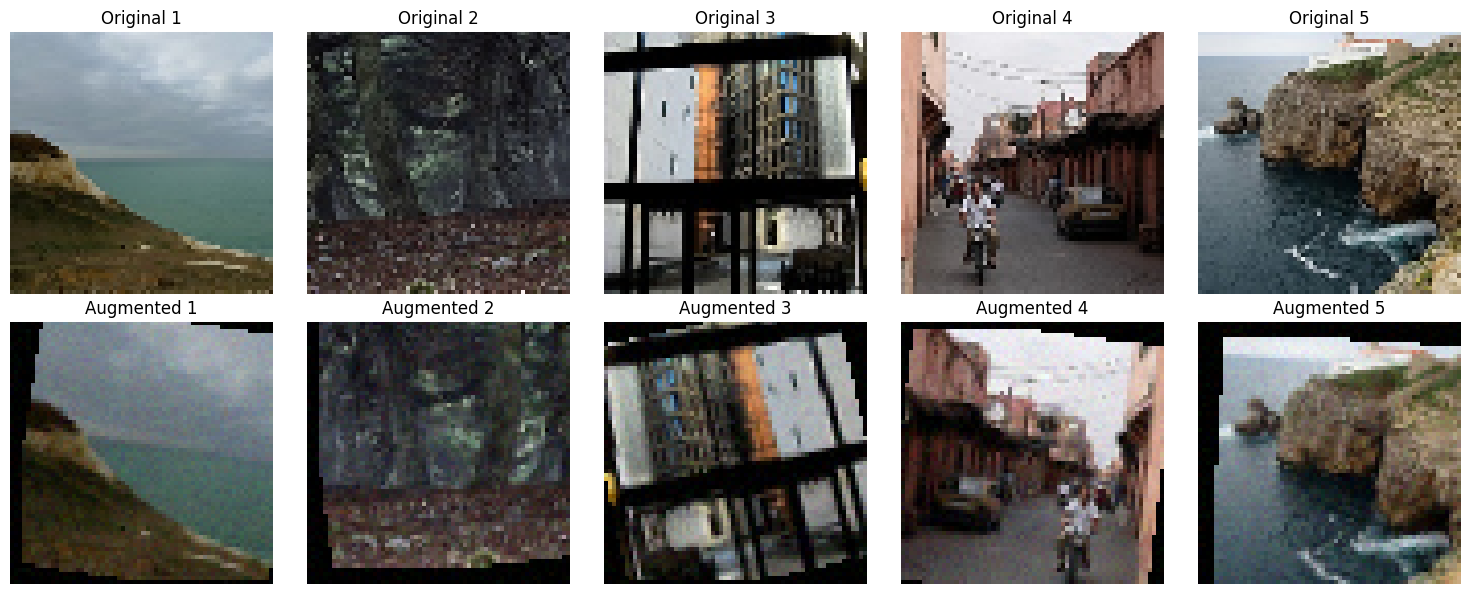

Loading 600 images from seg_test/seg_test...


Loading seg_test/seg_test: 100%|██████████| 600/600 [00:46<00:00, 12.98it/s]



✅ Data Loaded Successfully!
Train shapes: X=(2400, 64, 64, 3), y=(2400, 6)
Validation shapes: X=(600, 64, 64, 3), y=(600, 6)
Test shapes:  X=(600, 64, 64, 3), y=(600, 6)


In [3]:
# ==========================================
# Imports & Data Loading
# ==========================================
import numpy as np
from utils.data_loader import DataLoader
from utils.plotting import plot_augmentation_panel

# Initialize loader pointing to the extracted dataset
loader = DataLoader(data_dir=LOCAL_EXTRACT_PATH, target_size=(64, 64), batch_size=32)

# Load training data (using the folder structure of the Intel dataset)

samples = loader.get_samples_from_dir('seg_train/seg_train')
X_train_full, y_train_full = loader.load_all_data('seg_train/seg_train', augment=True, limit=3000) #subset_dir which is already there


plot_augmentation_panel(data_loader=loader, sample_list=samples, save_path="tests_summary/aug_panels/5.png")

#split 20% of train data for validation 
split_idx = int(len(X_train_full) * 0.8) # 80/20 split

X_train = X_train_full[:split_idx]
y_train = y_train_full[:split_idx]

X_val = X_train_full[split_idx:]
y_val = y_train_full[split_idx:]

X_test, y_test = loader.load_all_data('seg_test/seg_test', augment=False, limit=600)

# One-hot encode labels for the CNN/Softmax
num_classes = 6
y_train_oh = np.eye(num_classes)[y_train]
y_val_oh = np.eye(num_classes)[y_val]
y_test_oh = np.eye(num_classes)[y_test]

print(f"\n✅ Data Loaded Successfully!")

print(f"Train shapes: X={X_train.shape}, y={y_train_oh.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val_oh.shape}")
print(f"Test shapes:  X={X_test.shape}, y={y_test_oh.shape}")



In [4]:
!pip install mrmr-selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.7 MB/s eta 0:00:00


Converting to grayscale...


Gray Test: 100%|██████████| 600/600 [00:00<00:00, 9274.78it/s]


🚀 Found cached features! Loading...
Full feature vector length: 69 (expected 69)
Running MRMR to select top 58 out of 69 features...


100%|██████████| 58/58 [00:01<00:00, 35.54it/s]



Top Features Selected:
1. B_mean
2. grad_mean_magnitude
3. B_skewness
4. grad_mean_abs_gx
5. B_variance
6. global_mean
7. grad_mean_mag_desc
8. G_skewness
9. global_std
10. hist_bin_31
11. hist_bin_9
12. R_variance
13. hist_bin_11
14. G_mean
15. hist_bin_8
16. G_variance
17. hist_bin_33
18. hist_bin_10
19. grad_std_mag
20. hist_bin_7
21. hist_bin_34
22. hist_bin_12
23. hist_bin_6
24. hist_bin_32
25. hist_bin_36
26. hist_bin_28
27. hist_bin_30
28. hist_bin_5
29. hist_bin_13
30. hist_bin_35
31. R_mean
32. hist_bin_37
33. hist_bin_29
34. grad_max_magnitude
35. hist_bin_4
36. hist_bin_14
37. R_skewness
38. hist_bin_38
39. hist_bin_27
40. hist_bin_39
41. hist_bin_3
42. hist_bin_15
43. grad_mean_abs_gy
44. hist_bin_26
45. hist_bin_40
46. hist_bin_43
47. hist_bin_41
48. hist_bin_2
49. hist_bin_49
50. hist_bin_42
51. hist_bin_25
52. hist_bin_16
53. hist_bin_44
54. hist_bin_48
55. hist_bin_45
56. hist_bin_1
57. hist_bin_24
58. hist_bin_17
✅ MRMR selection done. Features reduced to 58.

KNN Acc

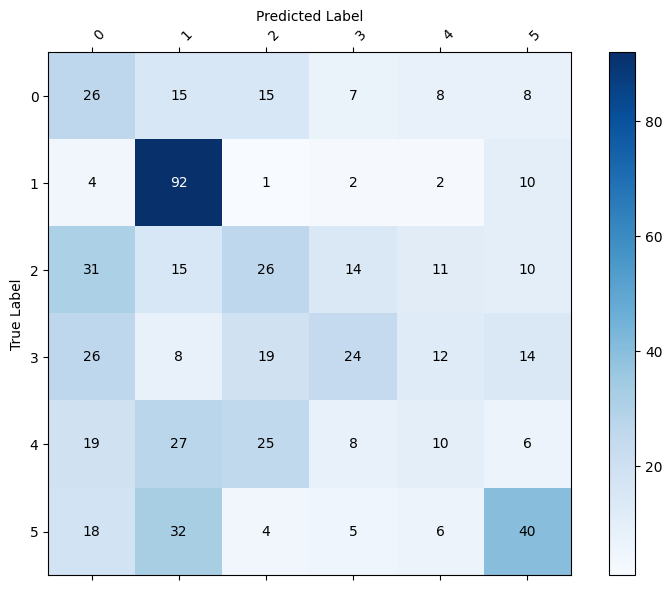

Evaluation saved to tests_summary/evaluation_reps/eval_20260511_175746_KNN_MRMR58


In [24]:
# ==========================================
#    KNN Pipeline with MRMR Feature Selection
# ==========================================

import numpy as np
from tqdm import tqdm
from minicv.io import rgb_to_gray
from models.KNN_model_def import KNNClassifier
from feature_ex.feature_pool import FeaturePool
from utils.eval_metrices import compute_metrics
from utils.logging import save_evaluation_report
from feature_ex.mrmr import MRMRSelector    # your class above
import os

# ------------------------------------------------------------------
# 1. Grayscale conversion (unchanged)
# ------------------------------------------------------------------
print("Converting to grayscale...")
X_train_gray = np.array([rgb_to_gray(img) for img in tqdm(X_train, desc="Gray Train")])
X_val_gray   = np.array([rgb_to_gray(img) for img in tqdm(X_val,   desc="Gray Val")])
X_test_gray  = np.array([rgb_to_gray(img) for img in tqdm(X_test,  desc="Gray Test")])

# ------------------------------------------------------------------
# 2. Feature Extraction (with caching – now we also save the names)
# ------------------------------------------------------------------
SAVE_PATH = "/content/drive/MyDrive/new_vision/features_cache_3000img"
os.makedirs(SAVE_PATH, exist_ok=True)

# We'll store the feature names alongside the arrays
names_path = f"{SAVE_PATH}/feature_names.npy"

if os.path.exists(f"{SAVE_PATH}/X_train_feats.npy"):
    print("🚀 Found cached features! Loading...")
    X_train_full = np.load(f"{SAVE_PATH}/X_train_feats.npy")
    X_val_full   = np.load(f"{SAVE_PATH}/X_val_feats.npy")
    X_test_full  = np.load(f"{SAVE_PATH}/X_test_feats.npy")
    feature_names = np.load(names_path, allow_pickle=True).tolist()
else:
    print("Extracting Features (This will take time, but we will save it)...")
    pool = FeaturePool(use_grayscale_gradients=True)
    # ★ capture both the array and the list of names
    X_train_full, feature_names = pool.process_dataset(X_train, X_train_gray, desc="Train Features")
    X_val_full,   _             = pool.process_dataset(X_val,   X_val_gray,   desc="Val Features")
    X_test_full,  _             = pool.process_dataset(X_test,  X_test_gray,  desc="Test Features")
    
    # Save everything
    np.save(f"{SAVE_PATH}/X_train_feats.npy", X_train_full)
    np.save(f"{SAVE_PATH}/X_val_feats.npy",   X_val_full)
    np.save(f"{SAVE_PATH}/X_test_feats.npy",  X_test_full)
    np.save(names_path, feature_names)          # save as numpy array of strings
    print("✅ Features extracted and saved to Drive.")

print(f"Full feature vector length: {X_train_full.shape[1]} (expected 69)")

# ------------------------------------------------------------------
# 3. MRMR Feature Selection
# ------------------------------------------------------------------
K_SELECT = 58  # choose how many top features to keep (you can tune this)

# Check for cached selector (optional – saves time if you re‑run the notebook)
selector_path = f"{SAVE_PATH}/mrmr_selected_indices_k{K_SELECT}.npy"

if os.path.exists(selector_path):
    print(f"🚀 Found cached MRMR selection for K={K_SELECT}. Loading...")
    selected_indices = np.load(selector_path)
    X_train_feats = X_train_full[:, selected_indices]
    X_val_feats   = X_val_full[:, selected_indices]
    X_test_feats  = X_test_full[:, selected_indices]
    # Reconstruct selector object if you need it later
    selector = MRMRSelector(k_features=K_SELECT)
    selector.selected_indices = selected_indices.tolist()
    selector.selected_feature_names = [feature_names[i] for i in selected_indices]
    print("Top features loaded from cache.")
else:
    selector = MRMRSelector(k_features=K_SELECT)

    # fit_transform on training data (requires integer labels, not one-hot)
    # y_train is assumed to be 1D integer labels (not one-hot).
    # If you only have y_train_oh, convert: y_train = np.argmax(y_train_oh, axis=1)
    X_train_feats = selector.fit_transform(X_train_full, y_train, feature_names)

    # Transform validation & test with the same selection
    X_val_feats  = selector.transform(X_val_full)
    X_test_feats = selector.transform(X_test_full)

    # Save the selected indices for next time
    np.save(selector_path, np.array(selector.selected_indices))
    print(f"✅ MRMR selection done. Features reduced to {K_SELECT}.")

# ------------------------------------------------------------------
# 4. KNN Training & Evaluation
# ------------------------------------------------------------------
knn = KNNClassifier()
knn.fit(X_train_feats, y_train)          # y_train must be integer labels

# Predict on validation set
y_pred_knn = knn.predict(X_val_feats, k=5)   # k=5 is a sensible default

# ★ Compute metrics using integer labels (y_val, not y_val_oh)
knn_metrics = compute_metrics(y_val, y_pred_knn, num_classes=6)
print(f"\nKNN Accuracy (with MRMR={K_SELECT} features): {knn_metrics['accuracy']:.4f}")

save_evaluation_report(knn_metrics, f"KNN_MRMR{K_SELECT}")

Epoch 001/5 | Train Loss: 2.1117 - Acc: 0.3488 | Val Loss: 1.3628 - Acc: 0.4420 | LR: 0.001000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment16
Epoch 002/5 | Train Loss: 1.2142 - Acc: 0.5363 | Val Loss: 1.3062 - Acc: 0.4777 | LR: 0.001000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment16
Epoch 003/5 | Train Loss: 1.0282 - Acc: 0.6525 | Val Loss: 1.1699 - Acc: 0.5446 | LR: 0.001000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment16
Epoch 004/5 | Train Loss: 0.8316 - Acc: 0.7063 | Val Loss: 1.1830 - Acc: 0.5804 | LR: 0.001000
Epoch 005/5 | Train Loss: 0.6786 - Acc: 0.7788 | Val Loss: 1.1519 - Acc: 0.5804 | LR: 0.001000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment16

--- Test Set Results ---
Accuracy:        0.5600
Macro F1:        0.5464
Weighted F1:     0.5409

Per class metrics:
  Class 0: Precision=0.367, Recall=0.250, F1=0.297
  Class 1: Precision=0.794, Reca

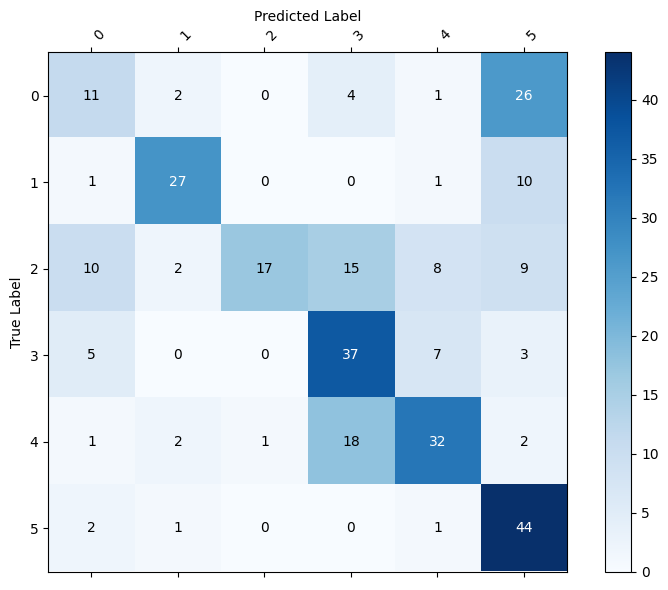

Evaluation saved to tests_summary/evaluation_reps/eval_20260510_193643_CustomCNN


In [ ]:
# ==========================================
# Custom CNN – Training & Evaluation
# ==========================================
import numpy as np
from models.CNN_model_def import my_cnn
from utils.loss import SoftmaxCrossEntropy       # adapt the import to your actual file
from utils.optimizer import Adam                 # or SGD
from utils.trainer import Trainer
from utils.logging import ExperimentLogger, save_evaluation_report
from utils.eval_metrices import compute_metrics  # note the spelling you use

# ------------------------------------------------------------------
# 0. Reproducibility
# ------------------------------------------------------------------
np.random.seed(42)

# ------------------------------------------------------------------
# 1. Reshape data to (batch, channels, height, width)
#    Your model expects input shape (C, H, W), so we transpose.
# ------------------------------------------------------------------
X_train_cnn = X_train.transpose(0, 3, 1, 2)   # (800, 3, 64, 64)
X_val_cnn   = X_val.transpose(0, 3, 1, 2)     # (200, 3, 64, 64)
X_test_cnn  = X_test.transpose(0, 3, 1, 2)    # (300, 3, 64, 64)

# ------------------------------------------------------------------
# 2. Build model, loss, optimizer, logger
# ------------------------------------------------------------------
input_shape = (3, 64, 64)
num_classes = 6

model = my_cnn(input_shape, num_classes)        # list of layer instances
loss_layer = SoftmaxCrossEntropy()              # your loss class
optimizer = Adam(lr=0.001)                      # or SGD(lr=0.01, momentum=0.9)

# Experiment logger (creates experiment_records/experimentX/)
logger = ExperimentLogger(base_dir="experiment_records")

# learning rate schedule 
from utils.optimizer import StepDecay
lr_schedule = StepDecay(initial_lr=0.001, drop_factor=0.5, epochs_drop=20)

# ------------------------------------------------------------------
# 3. Trainer instantiation
# ------------------------------------------------------------------
trainer = Trainer(
    model=model,
    loss_layer=loss_layer,
    optimizer=optimizer,
    logger=logger,
    lr_schedule=lr_schedule,   
    config={
        'l2_lambda': 1e-4,       # L2 regularization strength
        'clip_value': 1.0        # gradient clipping threshold
    }
)

# ------------------------------------------------------------------
# 4. Training (logs.csv, config.json, checkpoint.npz created automatically)
# ------------------------------------------------------------------
trainer.train(
    X_train_cnn, y_train_oh,      # one-hot labels
    X_val_cnn,   y_val_oh,
    epochs=5,
    batch_size=32,             #small patch
    patience=3                # early stopping
)

# ------------------------------------------------------------------
# 5. Test evaluation (using the best checkpoint)
# ------------------------------------------------------------------
# Load the best checkpoint (the Trainer does not automatically load at the end,
# so we explicitly restore it for final test evaluation)
logger.load_checkpoint(model, optimizer)   # loads weights & biases into 'model'

# Forward pass on test set
output = X_test_cnn
for layer in model:
    output = layer.forward(output)
test_probs = loss_layer.forward(output)      # should return softmax probabilities
y_pred = np.argmax(test_probs, axis=1)
y_true = np.argmax(y_test_oh, axis=1)


# Compute all required metrics
metrics = compute_metrics(y_true, y_pred, num_classes=6)

print("\n--- Test Set Results ---")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")
print("\nPer class metrics:")
per_class = metrics['per_class']
for cls, prec, rec, f1 in zip(range(num_classes),
                               per_class['precision'],
                               per_class['recall'],
                               per_class['f1']):
    print(f"  Class {cls}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

# Save evaluation report (confusion matrix plot + JSON metrics)
save_evaluation_report(metrics, "CustomCNN", base_dir="tests_summary/evaluation_reps")

Feature dimension: 58
Epoch 001/100 | Train Loss: 11.4697 - Acc: 0.2221 | Val Loss: 10.2133 - Acc: 0.2483 | LR: 0.010000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment65
Epoch 002/100 | Train Loss: 9.9781 - Acc: 0.2367 | Val Loss: 9.8942 - Acc: 0.2017 | LR: 0.010000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment65
Epoch 003/100 | Train Loss: 9.3675 - Acc: 0.2317 | Val Loss: 9.0869 - Acc: 0.2200 | LR: 0.010000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment65
Epoch 004/100 | Train Loss: 8.3938 - Acc: 0.2446 | Val Loss: 8.5559 - Acc: 0.2717 | LR: 0.010000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment65
Epoch 005/100 | Train Loss: 8.1637 - Acc: 0.2567 | Val Loss: 7.4359 - Acc: 0.2650 | LR: 0.010000
  -> Val loss improved! Best Checkpoint saved to experiment_records/experiment65
Epoch 006/100 | Train Loss: 7.1539 - Acc: 0.2579 | Val Loss: 6.6681 - Acc: 0.2850 | LR

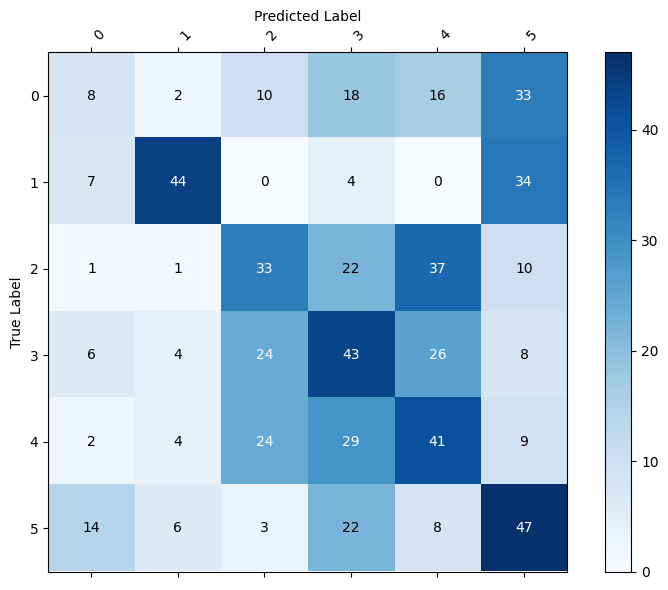

Evaluation saved to tests_summary/evaluation_reps/eval_20260511_180157_SoftmaxRegression_Features


In [38]:
# ==========================================
# Softmax Regression with MRMR Feature Selection
# ==========================================
import numpy as np
from models.Softmax_reg_def import build_softmax_regression
from utils.loss import SoftmaxCrossEntropy
from utils.optimizer import Adam             # or SGD
from utils.trainer import Trainer
from utils.logging import ExperimentLogger, save_evaluation_report
from utils.eval_metrices import compute_metrics

# ------------------------------------------------------------------
# 1. Input dimension from the extracted features
# ------------------------------------------------------------------
input_features = X_train_feats.shape[1]   # should be 19
num_classes = 6 
print(f"Feature dimension: {input_features}") 

# ------------------------------------------------------------------
# 2. Model, loss, optimizer, logger
# ------------------------------------------------------------------
softmax_model = build_softmax_regression(input_features, num_classes) 
loss_layer = SoftmaxCrossEntropy()
optimizer = Adam(lr=0.01)      # a single Dense layer can use a slightly higher LR          
logger = ExperimentLogger(base_dir="experiment_records")   # creates a new experiment folder

# ------------------------------------------------------------------
# 3. Trainer
# ------------------------------------------------------------------
# from utils.optimizer import StepDecay, ExponentialDecay, CosineAnnealing
# lr_schedule = CosineAnnealing(initial_lr=0.001)

trainer = Trainer(
    model=softmax_model,
    loss_layer=loss_layer,
    optimizer=optimizer,
    logger=logger,
   # lr_schedule=lr_schedule,  
    config={
        'l2_lambda': 1e-4,     # small L2 penalty to avoid overfitting
        'clip_value': 5.0
    }
)

# ------------------------------------------------------------------
# 4. Train
# ------------------------------------------------------------------
trainer.train(
    X_train_feats, y_train_oh,
    X_val_feats,   y_val_oh,
    epochs=100,
    batch_size=50,              # 69 features
    patience=10
)

# ------------------------------------------------------------------
# 5. Load best checkpoint & final test evaluation
# ------------------------------------------------------------------
logger.load_checkpoint(softmax_model, optimizer)

output = X_test_feats
for layer in softmax_model:
    output = layer.forward(output)
test_probs = loss_layer.forward(output)          # softmax probabilities
y_pred = np.argmax(test_probs, axis=1)
y_true = np.argmax(y_test_oh, axis=1)            # if y_test_oh is one‑hot, else use y_test directly

metrics = compute_metrics(y_true, y_pred, num_classes)
print(f"\nTest Accuracy: {metrics['accuracy']:.4f}")
print(f"Macro F1:      {metrics['macro_f1']:.4f}")
print(f"Weighted F1:   {metrics['weighted_f1']:.4f}")

per_class = metrics['per_class']
print("\nPer‑class metrics:")
for cls in range(num_classes):
    print(f"  Class {cls}: Precision={per_class['precision'][cls]:.3f}, "
          f"Recall={per_class['recall'][cls]:.3f}, "
          f"F1={per_class['f1'][cls]:.3f}")

save_evaluation_report(metrics, "SoftmaxRegression_Features")

Initializing EfficientNetV2 on device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 129MB/s] 


Epoch 001/20 | Train Loss: 0.9370 - Acc: 0.6500 | Val Loss: 0.7508 - Acc: 0.7983
  -> Best checkpoint saved (Val Loss: 0.7508)
Epoch 002/20 | Train Loss: 0.4510 - Acc: 0.8479 | Val Loss: 0.4838 - Acc: 0.8317
  -> Best checkpoint saved (Val Loss: 0.4838)
Epoch 003/20 | Train Loss: 0.2914 - Acc: 0.9025 | Val Loss: 0.5692 - Acc: 0.8217
Epoch 004/20 | Train Loss: 0.2052 - Acc: 0.9333 | Val Loss: 0.4362 - Acc: 0.8600
  -> Best checkpoint saved (Val Loss: 0.4362)
Epoch 005/20 | Train Loss: 0.1375 - Acc: 0.9550 | Val Loss: 0.6090 - Acc: 0.8533
Epoch 006/20 | Train Loss: 0.1676 - Acc: 0.9429 | Val Loss: 0.6381 - Acc: 0.8033
Epoch 007/20 | Train Loss: 0.1698 - Acc: 0.9437 | Val Loss: 0.5935 - Acc: 0.8250
Epoch 008/20 | Train Loss: 0.1151 - Acc: 0.9642 | Val Loss: 0.5048 - Acc: 0.8700
Epoch 009/20 | Train Loss: 0.0789 - Acc: 0.9758 | Val Loss: 0.5863 - Acc: 0.8383
Early stopping triggered at epoch 9

Test Accuracy (PyTorch eval): 0.8600
Accuracy:        0.8600
Macro F1:        0.8587
Weighted F1

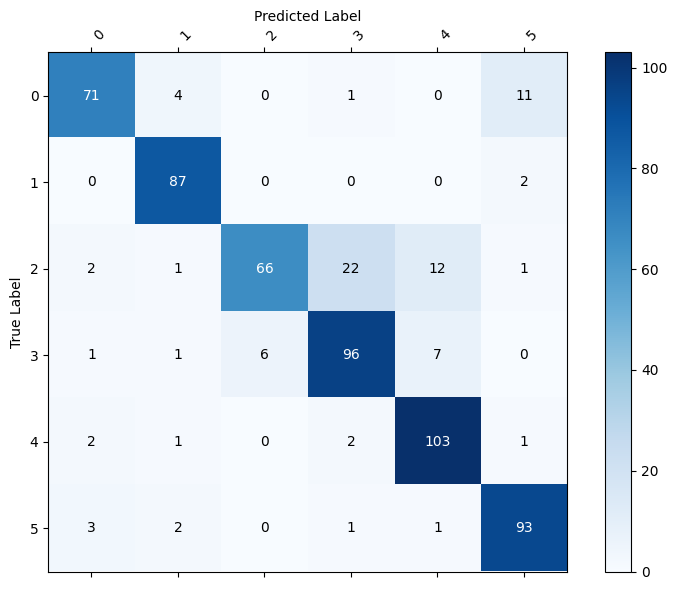

Evaluation saved to tests_summary/evaluation_reps/eval_20260511_172933_EfficientNetV2


In [5]:
# ==========================================
# EfficientNetV2-Small – Training & Evaluation
# ==========================================
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from models.Paper_model_def import EfficientNetV2Wrapper
from utils.logging import ExperimentLogger, save_evaluation_report
from utils.eval_metrices import compute_metrics

# ------------------------------------------------------------------
# 1. Convert NumPy arrays to PyTorch tensors & create DataLoaders
#    - The EfficientNetV2Wrapper expects RGB images in (N, C, H, W)
#    - Your current X_train shape: (N, 64, 64, 3) → need to transpose to (N,3,64,64)
#    - Labels: use integer indices (0-5), NOT one-hot
# ------------------------------------------------------------------
X_train_t = torch.tensor(X_train.transpose(0,3,1,2), dtype=torch.float32)  # (N,3,64,64)
y_train_t = torch.tensor(y_train, dtype=torch.long)                        # (N,)
X_val_t   = torch.tensor(X_val.transpose(0,3,1,2), dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
X_test_t  = torch.tensor(X_test.transpose(0,3,1,2), dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ------------------------------------------------------------------
# 2. Initialise the model, logger
# ------------------------------------------------------------------
model_wrapper = EfficientNetV2Wrapper(num_classes=6, learning_rate=0.001)
logger = ExperimentLogger(base_dir="experiment_records")

# Save configuration for this run
config = {
    'model': 'EfficientNetV2-S',
    'pretrained': 'ImageNet',
    'batch_size': batch_size,
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'num_epochs': 20,
    'early_stopping_patience': 5,
    'note': 'PyTorch native training loop'
}
logger.save_config(config)

# ------------------------------------------------------------------
# 3. Training loop with early stopping & checkpointing
# ------------------------------------------------------------------
num_epochs = 20
patience = 5
best_val_loss = float('inf')
no_improve = 0

for epoch in range(1, num_epochs+1):
    train_loss, train_acc = model_wrapper.train_epoch(train_loader)
    val_loss, val_acc = model_wrapper.evaluate(val_loader)

    # Log to CSV
    logger.log_epoch(epoch, train_loss, val_loss, train_acc, val_acc, model_wrapper.optimizer.param_groups[0]['lr'])

    print(f"Epoch {epoch:03d}/{num_epochs} | Train Loss: {train_loss:.4f} - Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} - Acc: {val_acc:.4f}")

    # Checkpointing (save PyTorch state dict)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        # Save using the logger's checkpoint file location, but as .pth
        checkpoint_path = logger.checkpoint_file.replace('.npz', '.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_wrapper.model.state_dict(),
            'optimizer_state_dict': model_wrapper.optimizer.state_dict(),
            'val_loss': val_loss,
            'config': config
        }, checkpoint_path)
        print(f"  -> Best checkpoint saved (Val Loss: {val_loss:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

# ------------------------------------------------------------------
# 4. Load best checkpoint & final test evaluation
# ------------------------------------------------------------------
best_checkpoint_path = logger.checkpoint_file.replace('.npz', '.pth')
checkpoint = torch.load(best_checkpoint_path)
model_wrapper.model.load_state_dict(checkpoint['model_state_dict'])
model_wrapper.model.to(model_wrapper.device)

# Evaluate on test set
test_loss, test_acc = model_wrapper.evaluate(test_loader)
print(f"\nTest Accuracy (PyTorch eval): {test_acc:.4f}")

# For detailed per-class metrics, we need predictions
model_wrapper.model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(model_wrapper.device)
        outputs = model_wrapper.model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# Compute all metrics and save evaluation report
metrics = compute_metrics(y_true, y_pred, num_classes=6)
print(f"Accuracy:        {metrics['accuracy']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

per_class = metrics['per_class']
print("\nPer‑class metrics:")
for cls in range(6):
    print(f"  Class {cls}: Precision={per_class['precision'][cls]:.3f}, "
          f"Recall={per_class['recall'][cls]:.3f}, "
          f"F1={per_class['f1'][cls]:.3f}")

save_evaluation_report(metrics, "EfficientNetV2")